

| 컬럼명 | 설명 |
| --- | --- |
| MedInc | 해당 지역의 가구 소득 중앙값 (단위: 10,000 달러) |
| HouseAge | 해당 지역 주택의 연식 |
| AveRooms | 가구당 평균 방 개수 |
| AveBedrms | 가구당 평균 침실 개수 |
| Population | 해당 지역의 전체 인구수 |
| AveOccup | 가구당 평균 거주 인원수 |
| Latitude | 해당 지역의 위도 |
| Longitude | 해당 지역의 경도 |
| MedHouseVal | 해당 지역의 주택 가격 중앙값 (단위: 100,000 달러) |

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv("data/fetch_california_housing.csv")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [47]:
import torch                    # 텐서 연산
import torch.nn as nn           # 신경망 모델 구성 (nn.Linear, nn.Sequential)
import torch.nn.functional as F # 함수형 연산 (F.relu, F.mse_loss)
import torch.optim as optim     # 최적화 알고리즘 (optim.SGD, optim.Adam)

In [48]:
df.columns


Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [49]:
cols = ["MedHouseVal","MedInc","AveRooms","AveOccup","HouseAge","Population"]

data = torch.from_numpy(df[cols].values).float() # 학습이 가능하도록 FloatTensor형태로 변환

data.shape

torch.Size([20640, 6])

In [50]:
data

tensor([[4.5260e+00, 8.3252e+00, 6.9841e+00, 2.5556e+00, 4.1000e+01, 3.2200e+02],
        [3.5850e+00, 8.3014e+00, 6.2381e+00, 2.1098e+00, 2.1000e+01, 2.4010e+03],
        [3.5210e+00, 7.2574e+00, 8.2881e+00, 2.8023e+00, 5.2000e+01, 4.9600e+02],
        ...,
        [9.2300e-01, 1.7000e+00, 5.2055e+00, 2.3256e+00, 1.7000e+01, 1.0070e+03],
        [8.4700e-01, 1.8672e+00, 5.3295e+00, 2.1232e+00, 1.8000e+01, 7.4100e+02],
        [8.9400e-01, 2.3886e+00, 5.2547e+00, 2.6170e+00, 1.6000e+01, 1.3870e+03]])

In [51]:
# 입력변수 X와 타겟값 y를 분리
X = data[:, 1:]
y = data[:, :1]


In [52]:
X.min(dim=0, keepdim=True).values

tensor([[0.4999, 0.8462, 0.6923, 1.0000, 3.0000]])

In [53]:

# X 데이터는 min-max 정규화
X_min = X.min(dim=0, keepdim=True).values
X_max = X.max(dim=0, keepdim=True).values

x = (X - X_min) / (X_max - X_min)
print(x.shape, y.shape) 

torch.Size([20640, 5]) torch.Size([20640, 1])


In [54]:
n_epochs = 2000       # 학습 반복횟수
learing_rate = 1e-3   # 학습률 (0.001)
paint_interval = 100  # 손실 출력 간격

In [55]:
model = nn.Linear(x.size(-1),y.size(-1))
model

Linear(in_features=5, out_features=1, bias=True)

In [56]:
# 모델의 파라미터를 자동으로 업데이트하는 최적화 함수
optimizer = optim.SGD(   # 확률적 경사하강법
    model.parameters(),  # 업데이트 할 가중치 및 편향
    lr=learing_rate      # 학습률
)

In [57]:
for i in range(n_epochs):
    y_hat = model(x) #순전파
    loss = F.mse_loss(y_hat,y) # 손실값

    optimizer.zero_grad() # 가중치 초기화
    loss.backward()       # 역전파
    
    optimizer.step()      # 파라미터 업데이트

    if (i + 1) % paint_interval == 0:
        print(f'Epoch {i + 1}의 loss : {loss:.4e}')

Epoch 100의 loss : 2.9123e+00
Epoch 200의 loss : 2.2287e+00
Epoch 300의 loss : 1.8310e+00
Epoch 400의 loss : 1.5988e+00
Epoch 500의 loss : 1.4624e+00
Epoch 600의 loss : 1.3816e+00
Epoch 700의 loss : 1.3329e+00
Epoch 800의 loss : 1.3029e+00
Epoch 900의 loss : 1.2836e+00
Epoch 1000의 loss : 1.2707e+00
Epoch 1100의 loss : 1.2614e+00
Epoch 1200의 loss : 1.2542e+00
Epoch 1300의 loss : 1.2483e+00
Epoch 1400의 loss : 1.2432e+00
Epoch 1500의 loss : 1.2384e+00
Epoch 1600의 loss : 1.2340e+00
Epoch 1700의 loss : 1.2297e+00
Epoch 1800의 loss : 1.2255e+00
Epoch 1900의 loss : 1.2214e+00
Epoch 2000의 loss : 1.2174e+00


torch.cat([y,y_hat],dim=1) : 실제값과 예측값을 열 방향으로 이어붙임
.detach_().numpy() : 텐서를 계산 그래프에서 분리하고, 넘파이 배열로 변환

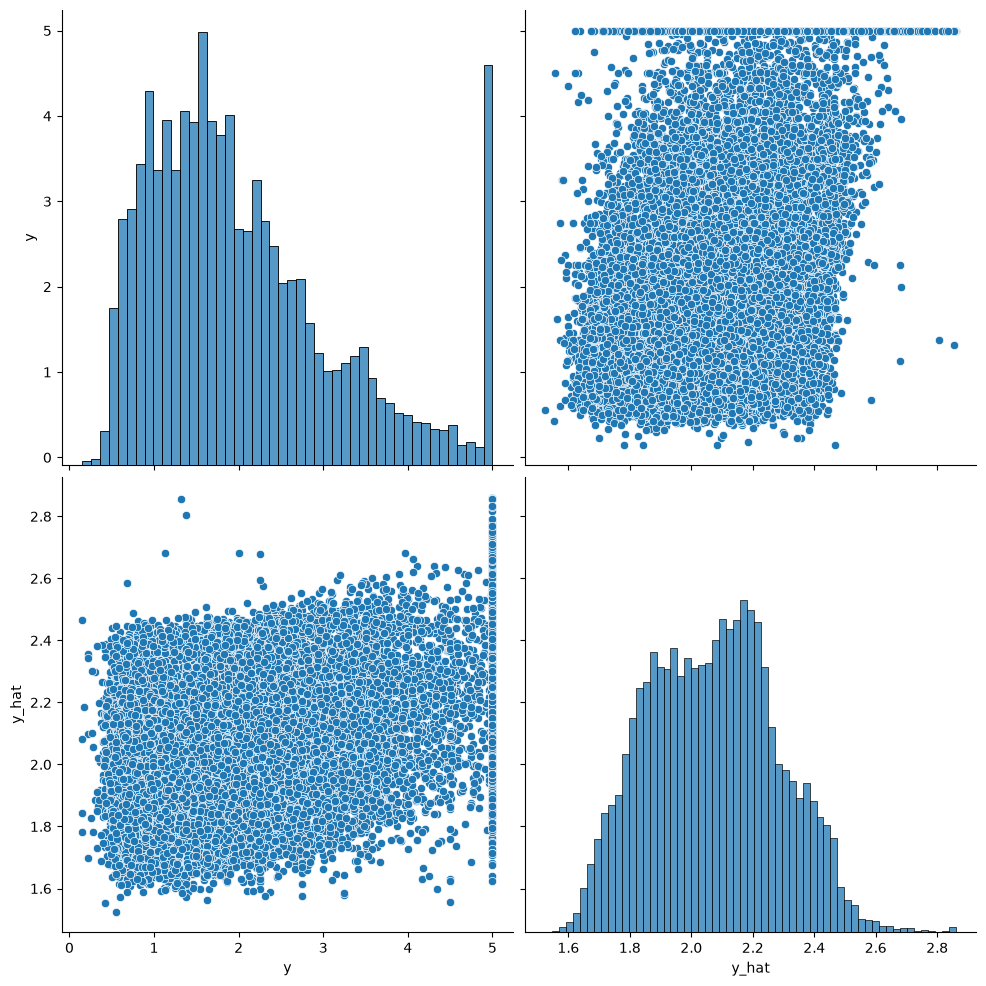

In [58]:

df = pd.DataFrame(
    torch.cat([y,y_hat], dim=1).detach_().numpy(),
    columns=["y","y_hat"]
)
sns.pairplot(df,height=5)
plt.show()